# 01 — Exploratory Data Analysis

A look at the BankChurners dataset before any modeling.

**Contents:**
1. Load and drop columns that aren't real features.
2. Structural inspection (shape, dtypes, summary stats).
3. Target class balance.
4. Missing-value audit.
5. Univariate distributions.
6. Bivariate analysis vs churn.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 3)

RANDOM_SEED = 42

## Load the data

The raw file is at `data/raw/BankChurners.csv` (not committed to the repo; download instructions are in the README).

In [3]:
df = pd.read_csv("../data/raw/BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,9.345e-05,1.0
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,5.686e-05,1.0
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,2.108e-05,1.0
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1.337e-04,1.0
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,2.168e-05,1.0


## Drop columns that aren't real features

- **`CLIENTNUM`** is a customer identifier, not a feature.
- The two `Naive_Bayes_Classifier_*` columns were appended to the dataset by the Kaggle uploader. They were trained on `Attrition_Flag`, so keeping them would leak the target into every model.

In [4]:
df = df.drop(columns=[
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
])
df.shape

(10127, 20)

## Structural inspection

A quick look at types, ranges, and category distributions before committing to a cleaning strategy.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  str    
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Open_To_Buy  

In [6]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000
mean,46.326,2.346,35.928,3.813,2.341,2.455,8631.954,1162.814,7469.140,0.760,4404.086,64.859,0.712,0.275
std,8.017,1.299,7.986,1.554,1.011,1.106,9088.777,814.987,9090.685,0.219,3397.129,23.473,0.238,0.276
min,26.000,0.000,13.000,1.000,0.000,0.000,1438.300,0.000,3.000,0.000,510.000,10.000,0.000,0.000
25%,41.000,1.000,31.000,3.000,2.000,2.000,2555.000,359.000,1324.500,0.631,2155.500,45.000,0.582,0.023
50%,46.000,2.000,36.000,4.000,2.000,2.000,4549.000,1276.000,3474.000,0.736,3899.000,67.000,0.702,0.176
75%,52.000,3.000,40.000,5.000,3.000,3.000,11067.500,1784.000,9859.000,0.859,4741.000,81.000,0.818,0.503
max,73.000,5.000,56.000,6.000,6.000,6.000,34516.000,2517.000,34516.000,3.397,18484.000,139.000,3.714,0.999


In [7]:
df.describe(include="object")

/var/folders/s1/ydqc1kqd1_l_3stqdlcsdygm0000gn/T/ipykernel_45735/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
count,10127,10127,10127,10127,10127,10127
unique,2,2,7,4,6,4
top,Existing Customer,F,Graduate,Married,Less than $40K,Blue
freq,8500,5358,3128,4687,3561,9436


### What we have

10,127 rows × 20 columns. No NaN values anywhere. Composition:

- 1 target: `Attrition_Flag` (Existing vs Attrited Customer)
- 14 numeric features (9 int, 5 float)
- 5 categoricals: `Gender`, `Education_Level`, `Marital_Status`, `Income_Category`, `Card_Category`

**Three things to carry forward:**

1. **`Education_Level`, `Marital_Status`, and `Income_Category` contain `"Unknown"` as a category.** No explicit NaNs in the data, but these are implicit missing values. Handled in the next section.
2. **`Credit_Limit` is heavily right-skewed** — mean $8.6k, max $34.5k, std $9.1k. Linear baseline models will need scaling.
3. **`Avg_Open_To_Buy` looks derived from `Credit_Limit`.** Same maximum value, very similar range. Almost certainly `Credit_Limit − Total_Revolving_Bal`. Expect strong correlation in the bivariate analysis.

## Target class balance

In [8]:
df["Attrition_Flag"].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [9]:
df["Attrition_Flag"].value_counts(normalize=True).round(3)

Attrition_Flag
Existing Customer    0.839
Attrited Customer    0.161
Name: proportion, dtype: float64

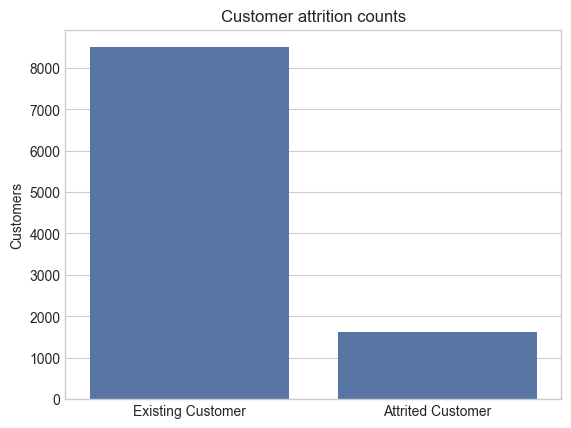

In [10]:
sns.countplot(x="Attrition_Flag", data=df)
plt.title("Customer attrition counts")
plt.xlabel("")
plt.ylabel("Customers")
plt.savefig("figures/target_balance.png", dpi=120, bbox_inches="tight");

I also create a clean binary `churned` column (1 = Attrited, 0 = Existing) for use in the rest of the notebook and in modeling.

In [11]:
df["churned"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)
df[["Attrition_Flag", "churned"]].head()

,Attrition_Flag,churned
0,Existing Customer,0
1,Existing Customer,0
2,Existing Customer,0
3,Existing Customer,0
4,Existing Customer,0


### What this means for modeling

The dataset is imbalanced: about 84% Existing vs 16% Attrited, a ~5:1 negative-to-positive ratio. This shapes several downstream choices:

- I'll use `class_weight="balanced"` for the logistic baseline.
- XGBoost gets `scale_pos_weight ≈ 5.2`.
- Accuracy is unreliable as a metric at this imbalance — I'll lean on AUC and PR-AUC instead.
- The default 0.5 prediction threshold is almost certainly wrong. Finding the right one is the whole point of the cost-analysis notebook.

## Missing values

Two passes: explicit `NaN` values, then implicit missingness via `"Unknown"` placeholders in the categorical columns.

In [12]:
df.isna().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
churned                     0
dtype: int64

In [13]:
unknowns = (df == "Unknown").sum()
unknowns[unknowns > 0]

Education_Level    1519
Marital_Status      749
Income_Category    1112
dtype: int64

### Handling "Unknown"

I treat `"Unknown"` as its own category rather than imputing or dropping.

- Imputing with the mode assumes those customers behave like the most common type, which they probably don't — missingness itself may carry signal (e.g. customers who declined to share income may differ behaviorally from those who shared).
- Dropping the rows would discard a meaningful share of the dataset — `Income_Category` alone has over 1,000 `"Unknown"` entries.
- Treating it as a category preserves any signal in the missingness for free: the OneHotEncoder in modeling will give it its own dummy column.

## Univariate distributions

One look at every feature on its own — shape, skew, dominant categories — before getting to the relationships with churn.

### Numeric features

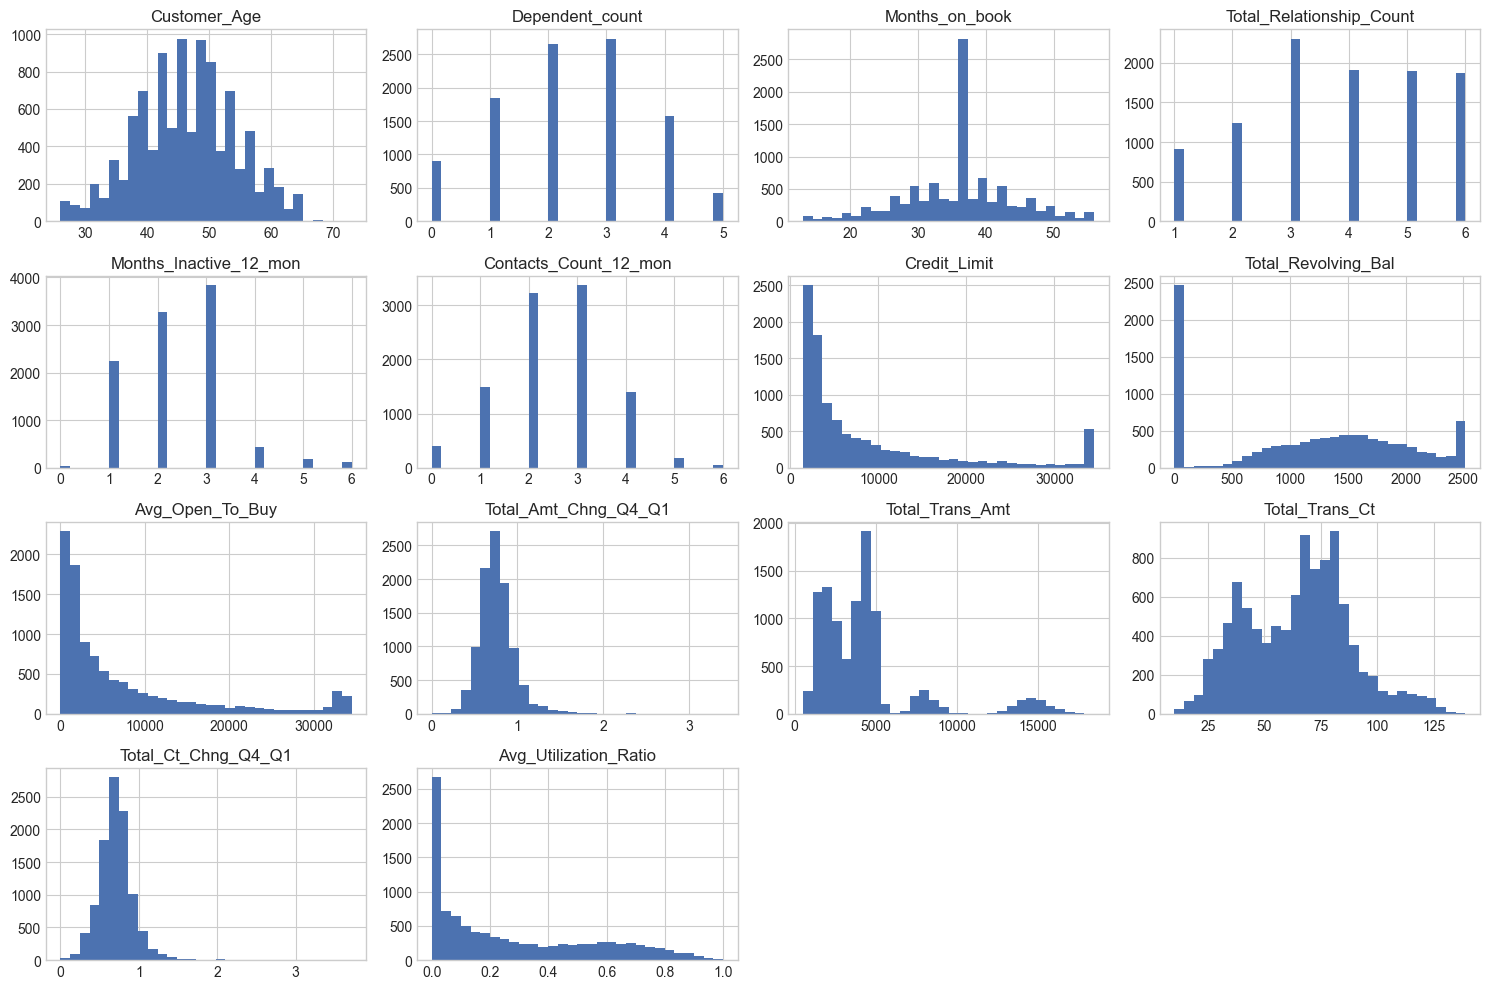

In [14]:
num_cols = df.select_dtypes(include="number").columns.drop("churned")
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.savefig("figures/numeric_distributions.png", dpi=120, bbox_inches="tight");

### Categorical features

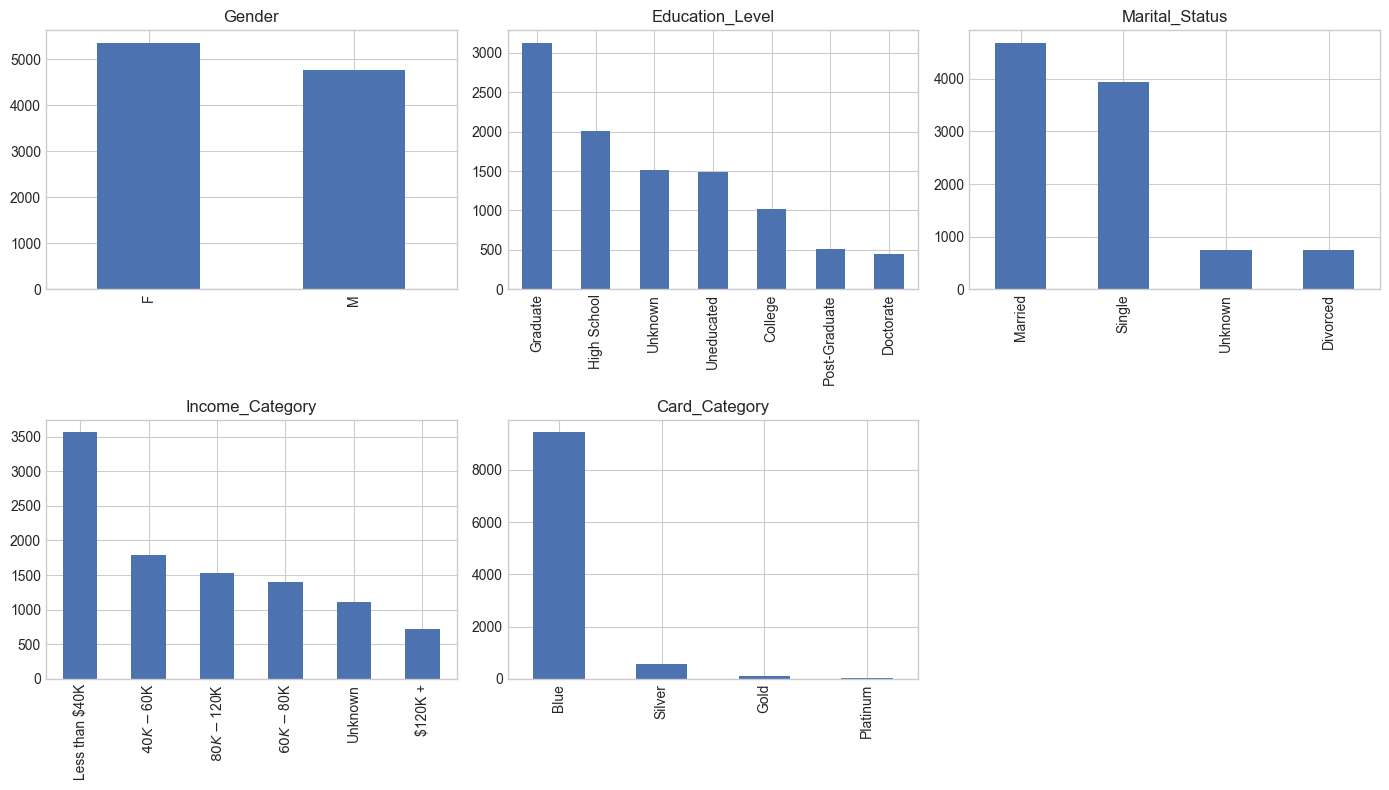

In [15]:
cat_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
axes.flatten()[5].set_visible(False)
plt.tight_layout();

### What stood out

- **`Credit_Limit` and `Avg_Open_To_Buy` are heavily right-skewed.** Most customers cluster below $5k, with a long tail running up to $34.5k. Their distributions are near-identical, confirming the structural suspicion that `Avg_Open_To_Buy` is `Credit_Limit − Total_Revolving_Bal`.
- **`Total_Revolving_Bal` has a noticeable spike at zero**, then a wide spread up to its $2,517 ceiling. The zero spike is customers who pay their statement in full every month — a behaviorally distinct group that may matter for churn.
- **`Card_Category` is dominated by `Blue` cards** — over 90% of customers. `Silver`, `Gold`, and `Platinum` together account for a tiny share. The model will have very little signal for the high-tier classes specifically; segment analysis on `Card_Category` in Phase 3 needs to keep that in mind.

## Bivariate analysis vs churn

For each feature, how does the distribution differ between customers who churned and those who stayed? Numeric features use boxplots split by `churned`; categoricals show the churn rate per category (with a red dashed line marking the overall 16% baseline).

### Numeric features vs churn

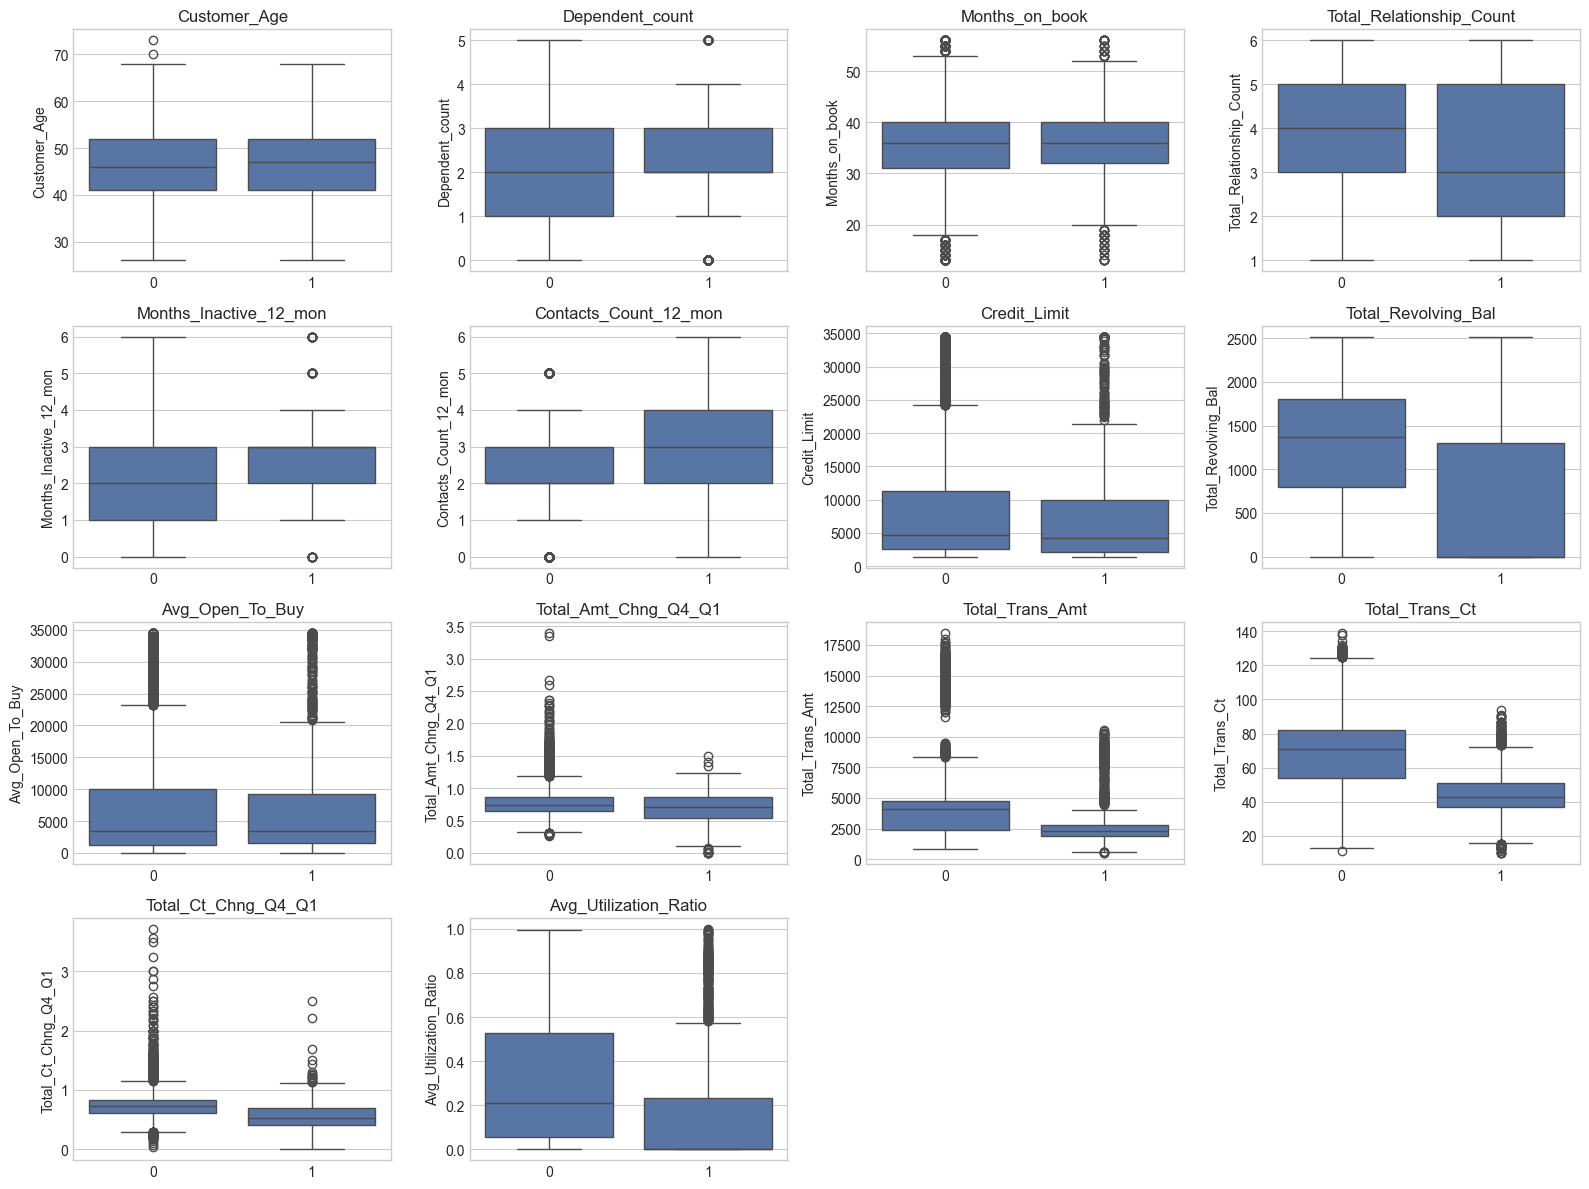

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x="churned", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("figures/numeric_features_vs_churn.png", dpi=120, bbox_inches="tight");

### Categorical features vs churn

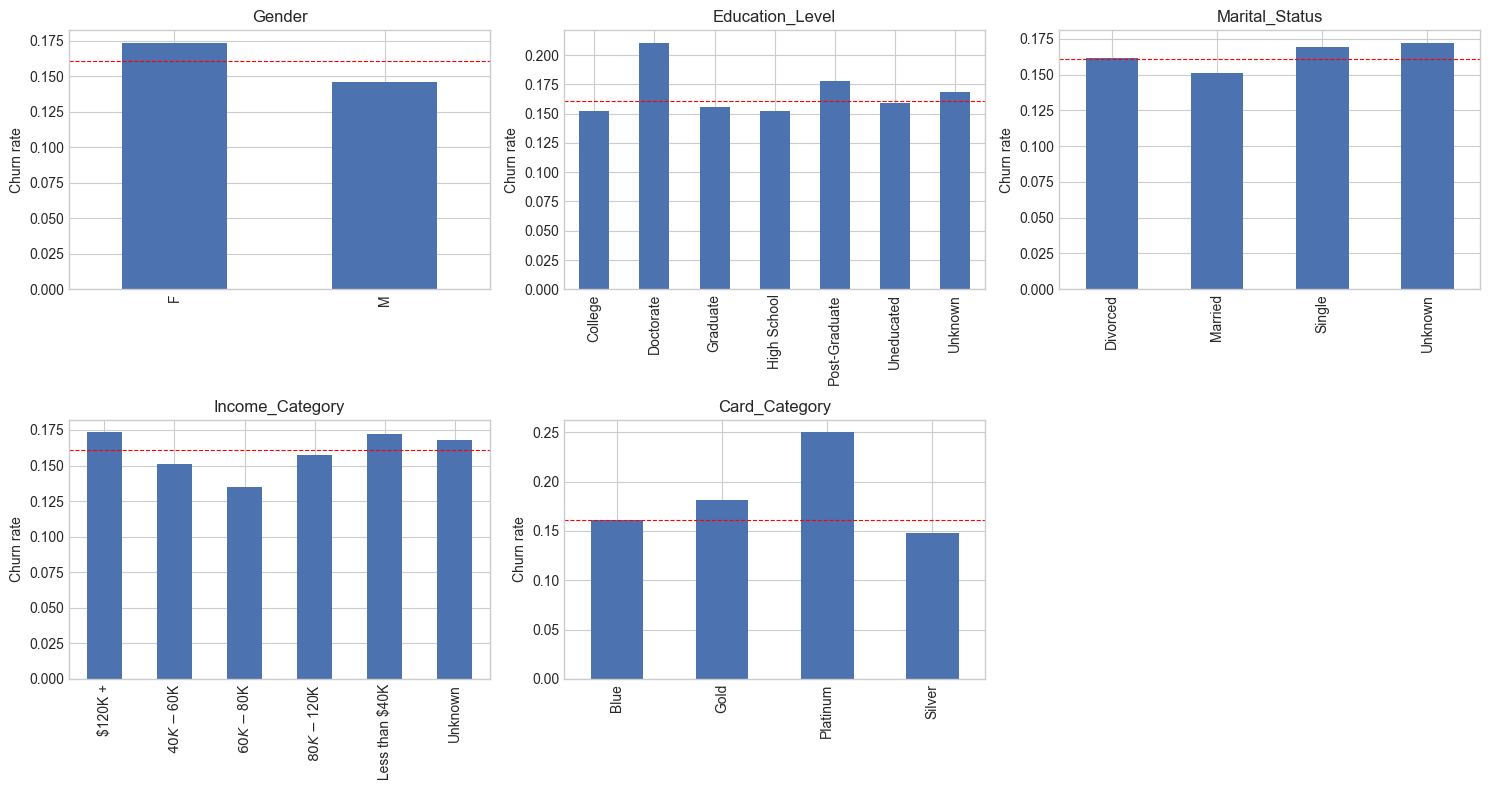

In [17]:
overall_churn_rate = df["churned"].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df.groupby(col)["churned"].mean().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate")
    ax.axhline(overall_churn_rate, color="red", linestyle="--", linewidth=0.8)
axes.flatten()[5].set_visible(False)
plt.tight_layout()
plt.savefig("figures/categorical_churn_rates.png", dpi=120, bbox_inches="tight");

### What stood out

- **Usage features dominate.** Customers who churn have ~46% less revolving balance, ~45% lower utilization ratio, and ~35% fewer transactions than those who stay. Engagement is by far the strongest signal in the data.
- **Churners contact the bank more often** — 26% more contacts in the prior 12 months. They're flagging issues to customer service before leaving.
- **Card tier doesn't equal stickiness.** Platinum cardholders churn at 25% (vs the 16% baseline). Higher-tier customers may have higher expectations and switch when those aren't met.

Age, tenure, gender, education, and income show essentially no churn signal — those features are mostly noise here.

## Customer segmentation

To check whether churn varies meaningfully across customer groups, I cut the data along three dimensions chosen for business relevance:

1. **Tenure** — `Months_on_book` split into terciles (New, Established, Long-tenured). Tenure showed essentially no churn signal on its own, so this segment is partly a negative-finding check.
2. **Activity** — `Total_Trans_Ct` split into terciles (Low, Medium, High). Transaction count was one of the strongest churn predictors; segments built on it should differ visibly in churn rate.
3. **Card tier** — `Card_Category` used as-is. Already categorical, with Platinum showing elevated churn in the bivariate.

Tercile cuts (`pd.qcut`) give roughly equal-sized buckets, which keeps per-segment comparisons honest on the skewed numeric features.

In [18]:
df["tenure_segment"] = pd.qcut(df["Months_on_book"], q=3, labels=["New", "Established", "Long-tenured"])
df["activity_segment"] = pd.qcut(df["Total_Trans_Ct"], q=3, labels=["Low", "Medium", "High"])

In [19]:
df["tenure_segment"].value_counts(sort=False)

tenure_segment
New             3485
Established     3485
Long-tenured    3157
Name: count, dtype: int64

In [20]:
df["activity_segment"].value_counts(sort=False)

activity_segment
Low       3458
Medium    3375
High      3294
Name: count, dtype: int64

### Churn rate per segment

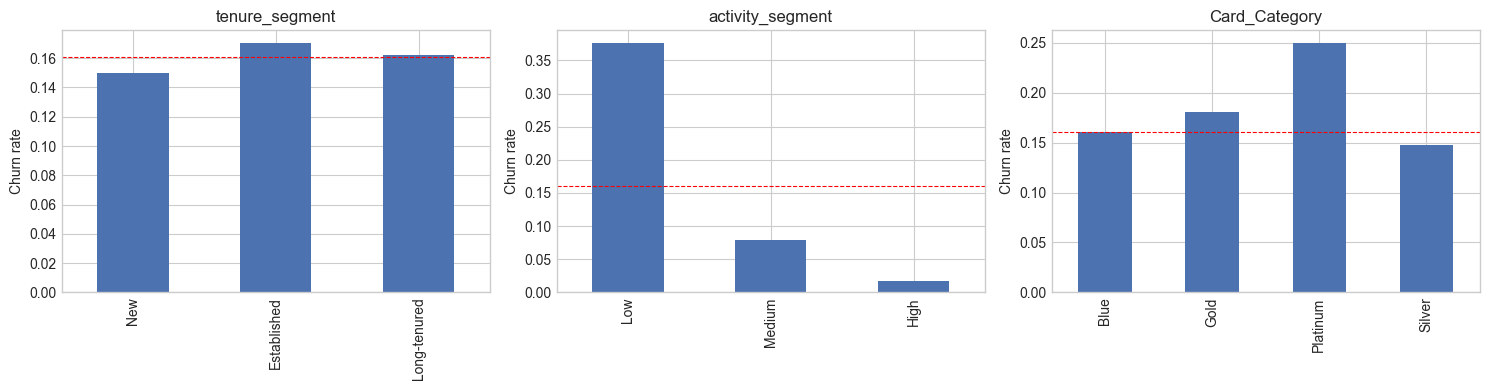

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, seg in zip(axes, ["tenure_segment", "activity_segment", "Card_Category"]):
    df.groupby(seg, observed=True)["churned"].mean().plot(kind="bar", ax=ax)
    ax.set_title(seg)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate")
    ax.axhline(overall_churn_rate, color="red", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("figures/churn_by_segment.png", dpi=120, bbox_inches="tight");

**What the segments reveal:**

- **Activity is the dominant story.** Low-activity customers churn at **37.7%**, while high-activity customers churn at **1.7%** — a 22× difference. This is by far the strongest segment-level signal in the dataset.
- **Tenure shows essentially no variation** — 15.0% / 17.0% / 16.2% across New / Established / Long-tenured, all close to the 16.1% baseline. Length of relationship with the bank does not predict churn on its own.
- **Card tier shows real but modest variation** — Silver 14.8%, Blue 16.1%, Gold 18.1%, Platinum 25.0%. Platinum stands out, but it's a small group (under 1% of customers), so the per-customer impact is limited.

### Cross-segment: tenure × activity

Single-dimension splits can hide interactions. Tenure on its own showed no churn signal, but maybe it matters once you control for activity (or vice versa). A heatmap of churn rate at every tenure × activity combination is the cleanest way to check.

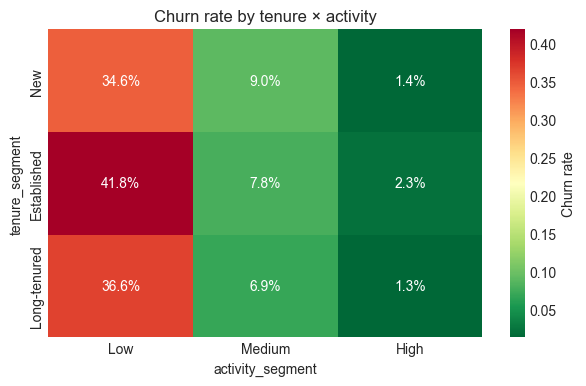

In [22]:
heatmap_data = df.pivot_table(
    index="tenure_segment",
    columns="activity_segment",
    values="churned",
    aggfunc="mean",
    observed=True,
)

plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap="RdYlGn_r", cbar_kws={"label": "Churn rate"})
plt.title("Churn rate by tenure × activity")
plt.savefig("figures/heatmap_tenure_activity.png", dpi=120, bbox_inches="tight");

**Reading the heatmap:**

- **Activity overwhelms tenure.** Within each tenure row, churn rate falls by a factor of 20–30 from Low to High activity. Within each activity column, churn rate barely moves with tenure (a few percentage points at most).
- **The worst cell is Established + Low-activity at 41.8%** — established customers whose engagement drops are the most at-risk group. New + Low (34.6%) and Long-tenured + Low (36.6%) are also bad but slightly less so.
- **The safest cells are the High-activity column** (1.3% – 2.3% across all tenure buckets). High engagement essentially immunises customers regardless of how long they've been with the bank.

The interaction story: there isn't much. Activity is the dominant axis; tenure adds minor seasoning. This is itself a useful finding — a retention strategy targeting tenure groups would mostly miss the actual risk, while a strategy targeting low-activity customers would catch most of it.

## Quantified takeaways

Five segment-level findings, each with a concrete number. These are the bullets that go into the README and into interview discussions about the project.

1. **Activity is the single dominant signal in the dataset.** Customers in the bottom third by transaction count churn at **37.7%**; customers in the top third churn at **1.7%** — a 22× gap. No other segmentation comes close to this contrast.

2. **Tenure alone does not predict churn.** New, Established, and Long-tenured customers churn at 15.0%, 17.0%, and 16.2% respectively — all within ±1 point of the 16.1% baseline. Length of the customer relationship is essentially noise as a marginal predictor.

3. **The most at-risk cell is Established + Low-activity, at 41.8% churn** — 2.6× the overall rate. Established customers whose engagement drops are the highest-priority intervention target.

4. **High engagement essentially immunises against churn.** In the High-activity column of the tenure × activity heatmap, churn ranges from 1.3% to 2.3% regardless of tenure — about one-tenth of the baseline rate. Retention efforts targeted at low-activity customers catch nearly all the risk; targeting other dimensions misses most of it.

5. **Higher card tier ≠ stickier customer.** Platinum cardholders churn at **25.0%**, well above the 16% baseline and the Silver rate of 14.8%. The Platinum population is small (under 1% of customers), so the absolute volume of at-risk Platinum customers is modest — but the elevated rate is a flag that premium service is not preventing exit on its own.